Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


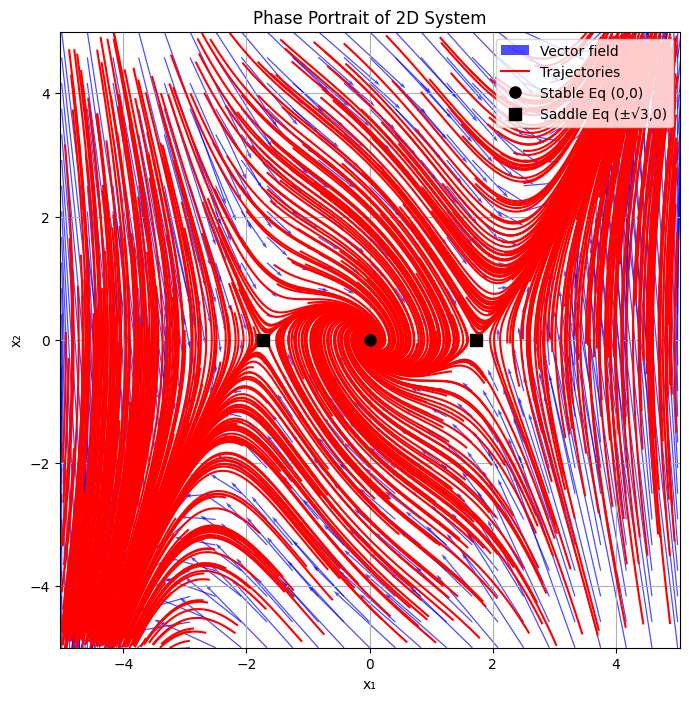

Generated 700 random trajectories
Rejected 0 short trajectories during generation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def f1(x1, x2):
    return x2

def f2(x1, x2):
    return -x1 + (1/3)*x1**3 - x2

x1_range = np.linspace(-5, 5, 25)
x2_range = np.linspace(-5, 5, 25)
x1, x2 = np.meshgrid(x1_range, x2_range)
U = f1(x1, x2)
V = f2(x1, x2)

plt.figure(figsize=(8, 8))
quiv = plt.quiver(
    x1, x2, U, V,
    color='b',
    alpha=0.7,
    angles='xy',
    scale_units='xy',
    scale=5,
    width=0.002          
)
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Phase Portrait of 2D System')
plt.axis('equal')
plt.xlim([-5, 5])
plt.ylim([-5, 5])
plt.grid(True)

num_trajectories = 700
np.random.seed(42)

def system(t, z):
    x1, x2 = z
    return [f1(x1, x2), f2(x1, x2)]

lines = []
t_span = [0, 6]
all_trajectories = []
min_length = 7
i = 0 
rejected_count = 0
while len(all_trajectories) < num_trajectories:
    ic = np.random.uniform(-5, 5, size=2)
    sol = solve_ivp(system, t_span, ic, t_eval=np.linspace(*t_span, 400))
    max_val = max(np.abs(sol.y[0]).max(), np.abs(sol.y[1]).max())
    solution = []
    i = 0
    for point_0 in sol.y[0]:
        point_1 = sol.y[1][i]
        if point_0 < 5 and point_0 > -5 and point_1 < 5 and point_1 > -5:
            solution.append([point_0, point_1])
        i += 1
            
    all_trajectories.append(solution)
    line, = plt.plot([k[0] for k in solution],  [k[1] for k in solution], 'r', linewidth=1.5)
    lines.append(line)


eq1 = plt.plot(0, 0, 'ko', markersize=8)
eq2 = plt.plot(3**0.5, 0, 'ks', markersize=8)
eq3 = plt.plot(-3**0.5, 0, 'ks', markersize=8)
plt.legend(
    [quiv, lines[0], eq1[0], eq2[0]],
    ['Vector field', 'Trajectories', 'Stable Eq (0,0)', 'Saddle Eq (±√3,0)'],
    loc='upper right'
)
plt.show()
print(f"Generated {num_trajectories} random trajectories")
print(f"Rejected {rejected_count} short trajectories during generation.")

In [2]:
import torch.nn as nn
import math
import torch 
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

class AttentionHead(nn.Module):
    def __init__(self, n_embd, head_size, dropout_rate):
        super().__init__()
        self.head_size = head_size
        self.w_key = nn.Linear(n_embd, head_size, bias=False)
        self.w_query = nn.Linear(n_embd, head_size, bias=False)
        self.w_value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, embedded_input, block_size):
        K = self.w_key(embedded_input)
        Q = self.w_query(embedded_input)
        V = self.w_value(embedded_input)
        raw_attention_scores = (Q @ K.transpose(-2,-1)) * (1.0 / math.sqrt(self.head_size))
        masked_attention_scores = raw_attention_scores.masked_fill(
            torch.tril(torch.ones(block_size, block_size)) == 0, float('-inf')
        )
        attention_probabilities = self.dropout(F.softmax(masked_attention_scores, dim=-1))
        return attention_probabilities @ V

class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate):
        super().__init__()
        self.heads = nn.ModuleList([
            AttentionHead(n_embd, head_size, dropout_rate) for _ in range(num_heads)
        ])
        self.w_attn_output = nn.Linear(head_size * num_heads, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, embedded_input, block_size):
        head_outputs = [head(embedded_input, block_size) for head in self.heads]
        concatenated = torch.cat(head_outputs, dim=-1)
        return self.dropout(self.w_attn_output(concatenated))
    
class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout_rate):
        super().__init__()
        self.w_ffn = nn.Linear(n_embd, 4 * n_embd)
        self.w_ffn_output = nn.Linear(4 * n_embd, n_embd)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        FFN_activations = F.relu(self.w_ffn(x))
        return self.dropout(self.w_ffn_output(FFN_activations))
    
class TransformerBlock(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate):
        super().__init__()
        self.attention = MultiHeadAttention(n_embd, num_heads, head_size, dropout_rate)
        self.norm_attn_gain = nn.Parameter(torch.ones(n_embd))
        self.norm_attn_bias = nn.Parameter(torch.zeros(n_embd))
        self.ffn = FeedForward(n_embd, dropout_rate)
        self.norm_logits_gain = nn.Parameter(torch.ones(n_embd))
        self.norm_logits_bias = nn.Parameter(torch.zeros(n_embd))
    
    def forward(self, embedded_input, block_size):
        # Attention
        attention_output = self.attention(embedded_input, block_size)
        # Add + Norm
        FFN_in_raw = attention_output + embedded_input
        FFN_in_normalized = self.norm_attn_gain * (FFN_in_raw - FFN_in_raw.mean(dim=-1, keepdim=True)) + self.norm_attn_bias
        # FFN
        FFN_output = self.ffn(FFN_in_normalized)
        # Add + Norm
        logits_raw = FFN_output + FFN_in_normalized
        logits_normalized = self.norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) + self.norm_logits_bias
        return logits_normalized


class TransformerModel(nn.Module):
    def __init__(self, n_embd, num_heads, head_size, dropout_rate, num_layers=1):
        super().__init__()
        self.embed = nn.Linear(2, n_embd, bias=False)
        self.blocks = nn.ModuleList([
            TransformerBlock(n_embd, num_heads, head_size, dropout_rate) for _ in range(num_layers)
        ])
        self.w_logits_output = nn.Linear(n_embd, 2)
    
    def forward(self, input_data, block_size):
        embedded_input = self.embed(input_data)
        x = embedded_input
        for block in self.blocks:
            x = block(x, block_size)
        # Linear
        logits = self.w_logits_output(x)
        return logits



# Train Model
block_size = 16
n_embd = 128
num_heads = 4 # must be factor of 10 (block size)
batch_size = 64
head_size = n_embd // num_heads
dropout_rate = 0.1
num_layers = 3
n_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def f1(x1, x2):
    return x2
def f2(x1, x2):
    return -x1 + (1/3)*x1**3 - x2
def system(t, z):
    x1, x2 = z
    return [f1(x1, x2), f2(x1, x2)]
print("Generating trajectories...")
num_trajectories = 800
t_span = [0, 6]
all_trajectories = []
np.random.seed(42)
while len(all_trajectories) < num_trajectories:
    ic = np.random.uniform(-5, 5, size=2)
    sol = solve_ivp(system, t_span, ic, t_eval=np.linspace(*t_span, 100))
    traj = np.vstack(sol.y).T
    if np.abs(traj).max() < 6:
        all_trajectories.append(traj)
print(f"Generated {len(all_trajectories)} valid trajectories.")
all_data = np.vstack(all_trajectories)
mean = np.mean(all_data, axis=0)
std = np.std(all_data, axis=0)
def normalize(data):
    return (data - mean) / (std + 1e-6)
def denormalize(data):
    return data * (std + 1e-6) + mean
X_list = []
Y_list = []
for traj in all_trajectories:
    traj_norm = normalize(traj)
    for i in range(len(traj_norm) - block_size):
        seq = traj_norm[i:i+block_size]
        target_next_point = traj_norm[i+block_size]
        current_last_point = traj_norm[i+block_size-1]
        target_delta = target_next_point - current_last_point
        X_list.append(seq)
        Y_list.append(target_delta)
X_data = torch.tensor(np.array(X_list), dtype=torch.float32)
Y_data = torch.tensor(np.array(Y_list), dtype=torch.float32)
dataset = TensorDataset(X_data, Y_data)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)




model = TransformerModel(n_embd, num_heads, head_size, dropout_rate, num_layers)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
print("Starting training...")
epochs = 10
model.train()
for epoch in range(epochs):
    total_loss = 0
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        
        optimizer.zero_grad()
        # Predict delta
        pred_delta = model(X_batch, block_size)[:, -1, :]
        
        loss = criterion(pred_delta, Y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradient clipping
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.6f}")

Generating trajectories...
Generated 800 valid trajectories.
Starting training...
Epoch 1/10 | Loss: 0.003014
Epoch 2/10 | Loss: 0.000032
Epoch 3/10 | Loss: 0.000023
Epoch 4/10 | Loss: 0.000019
Epoch 5/10 | Loss: 0.000018
Epoch 6/10 | Loss: 0.000024
Epoch 7/10 | Loss: 0.000015
Epoch 8/10 | Loss: 0.000011
Epoch 9/10 | Loss: 0.000007
Epoch 10/10 | Loss: 0.000016


Generating inference plots...


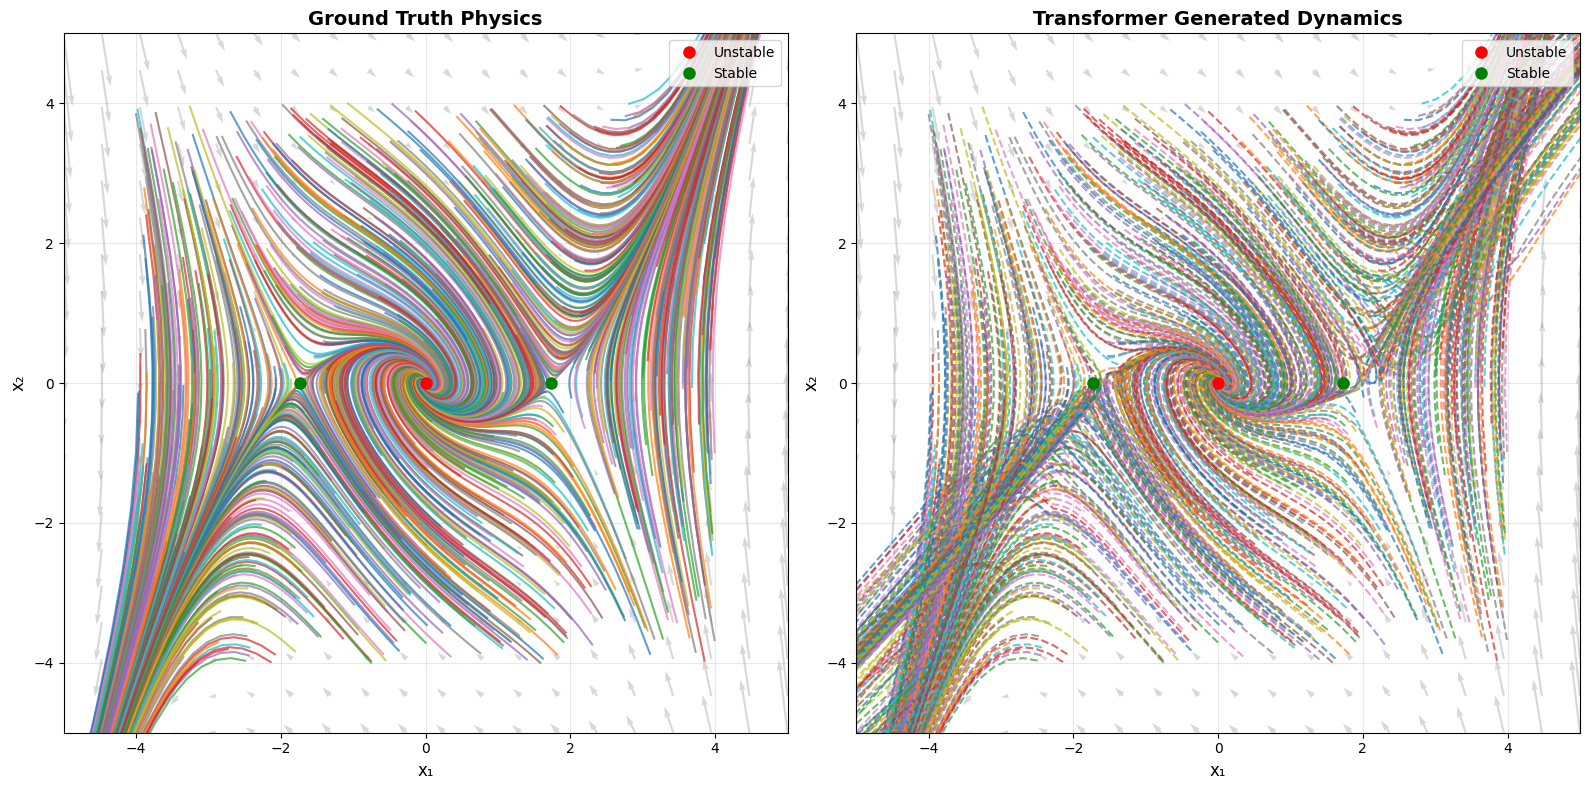

Visualization complete!


In [3]:
# ==========================================
# INFERENCE & VISUALIZATION
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

model.eval()
print("Generating inference plots...")

# Setup plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 1. Ground Truth Phase Portrait (Vector Field)
x1_range = np.linspace(-5, 5, 20)
x2_range = np.linspace(-5, 5, 20)
X1, X2 = np.meshgrid(x1_range, x2_range)
U = f1(X1, X2)
V = f2(X1, X2)
ax1.quiver(X1, X2, U, V, color='gray', alpha=0.3)
ax2.quiver(X1, X2, U, V, color='gray', alpha=0.3)

# 2. Generate Autoregressive Trajectories
np.random.seed(123)  # Different seed for test trajectories
num_test_traj = 1000
start_points = np.random.uniform(-4, 4, size=(num_test_traj, 2))

for idx, start in enumerate(start_points):
    # --- A. Get True Trajectory ---
    sol = solve_ivp(system, [0, 10], start, t_eval=np.linspace(0, 10, 200))
    true_traj = sol.y.T
    
    ax1.plot(true_traj[:, 0], true_traj[:, 1], linewidth=1.5, alpha=0.7)
    
    # --- B. Neural Network Prediction ---
    # Initialize with first 'block_size' points from truth to prime the model
    initial_seq = normalize(true_traj[:block_size])
    current_seq = torch.tensor(initial_seq, dtype=torch.float32).unsqueeze(0).to(device)
    
    pred_traj = list(initial_seq)
    
    with torch.no_grad():
        for _ in range(200 - block_size):
            # Predict delta
            delta_pred = model(current_seq, block_size)[:, -1, :]  # Shape (1, 2)
            
            # Calculate next point: last_point + delta
            last_point = current_seq[:, -1, :]
            next_point = last_point + delta_pred
            
            # Update sequence: slide window
            next_point_unsqueezed = next_point.unsqueeze(1)
            current_seq = torch.cat((current_seq[:, 1:, :], next_point_unsqueezed), dim=1)
            
            pred_traj.append(next_point.cpu().numpy()[0])
    
    # Denormalize for plotting
    pred_traj_np = denormalize(np.array(pred_traj))
    
    # Plot
    ax2.plot(pred_traj_np[:, 0], pred_traj_np[:, 1], linewidth=1.5, alpha=0.7, linestyle='--')

# Styling
ax1.set_title("Ground Truth Physics", fontsize=14, fontweight='bold')
ax2.set_title("Transformer Generated Dynamics", fontsize=14, fontweight='bold')

for ax in [ax1, ax2]:
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel('x₁', fontsize=12)
    ax.set_ylabel('x₂', fontsize=12)
    ax.grid(True, alpha=0.3)
    # Mark equilibrium points
    ax.plot(0, 0, 'ro', markersize=8, label='Unstable')
    ax.plot(np.sqrt(3), 0, 'go', markersize=8, label='Stable')
    ax.plot(-np.sqrt(3), 0, 'go', markersize=8)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("Visualization complete!")

# Verification

In [ ]:
import random
import numpy as np
from sklearn import linear_model as lm
import copy
import matplotlib.pyplot as plt

dimension_5_total = 0
total_dimensions = 0

def batched_inference(inputs_array):
    # inputs_array comes in as shape (N, 32) -> Flattened trajectory of 16 points x 2 coords
    # We must reshape it to (N, 16, 2) for the Transformer
    batch_input_np = inputs_array.reshape(-1, block_size, 2)
    
    # 1. NORMALIZE INPUTS
    # We use the global 'mean' and 'std' from your training script
    # Broadcasting: (N, 16, 2) - (2,) works automatically
    batch_input_norm = (batch_input_np - mean) / (std + 1e-6)
    
    # Convert to Tensor
    batch_input_tensor = torch.tensor(batch_input_norm, dtype=torch.float32).to(device)
    
    model.eval()
    with torch.no_grad():
        # 2. RUN MODEL
        # Output shape: (N, block_size, 2)
        logits = model(batch_input_tensor, block_size)
        
        # Take the prediction for the last time step
        # This is the predicted NORMALIZED delta
        pred_delta_norm = logits[:, -1, :].cpu().numpy()
        
    # 3. DENORMALIZE OUTPUT (Optional but recommended for physical verification)
    # The model predicts normalized delta. To verify physics, we scale it back.
    pred_delta_real = pred_delta_norm * (std + 1e-6)
    
    return pred_delta_real

def get_data(box, train_point_num, test_point_num):
    total_points = train_point_num + test_point_num
    
    # 1. Vectorized Random Generation (No loops!)
    # Create arrays of low/high bounds for the box
    lows = np.array([b[0] for b in box])
    highs = np.array([b[1] for b in box])
    
    # Generate (Total_Points, Dimensions) array
    points_x = np.random.uniform(lows, highs, size=(total_points, len(box)))
    
    # 2. Run Batched Inference (15,000 points in one pass)
    points_y = batched_inference(points_x)
    
    # 3. Split and Return
    return (points_x[:train_point_num], points_y[:train_point_num], 
            points_x[test_point_num:], points_y[test_point_num:])

def train_test_model(train_points_x, train_points_y, test_points_x, test_points_y):
    # train_points_y is now 2D: (N, 2)
    
    # --- Model A: Predict Delta x1 ---
    model_x1 = lm.LinearRegression()
    model_x1.fit(train_points_x, train_points_y[:, 0])
    
    # --- Model B: Predict Delta x2 ---
    model_x2 = lm.LinearRegression()
    model_x2.fit(train_points_x, train_points_y[:, 1])
    
    # --- Check Errors ---
    pred_x1 = model_x1.predict(test_points_x)
    pred_x2 = model_x2.predict(test_points_x)
    
    # Calculate errors for both dimensions
    error_x1 = np.abs(pred_x1 - test_points_y[:, 0])
    error_x2 = np.abs(pred_x2 - test_points_y[:, 1])
    
    # The error for this box is the WORST case of either model
    max_error = np.max(np.maximum(error_x1, error_x2))
    
    # Return BOTH models as a tuple
    return max_error, (model_x1, model_x2)
    

def choose_split(box, train_point_num, test_point_num):
    min_error = np.inf
    best_box_model_pairs = []
    best_dimension = -1
    for dimension in range(len(box)):
        min_range, max_range = box[dimension]
        divider = (min_range + max_range) / 2
        box1 = copy.deepcopy(box)
        box1[dimension] = [divider, max_range]
        box2 = copy.deepcopy(box)
        box2[dimension] = [min_range, divider]
        train_points_x1, train_points_y1, test_points_x1, test_points_y1 = get_data(box1, train_point_num, test_point_num)
        error1, model1 = train_test_model(train_points_x1, train_points_y1, test_points_x1, test_points_y1)
        train_points_x2, train_points_y2, test_points_x2, test_points_y2 = get_data(box2, train_point_num, test_point_num)
        error2, model2 = train_test_model(train_points_x2, train_points_y2, test_points_x2, test_points_y2)
        if error1 + error2 < min_error:
            min_error = error1 + error2
            best_box_model_pairs = [{"box": box1, "model": model1}, {"box": box2, "model": model2}]
            best_dimension = dimension
    print(f"Chose to split dimension {best_dimension} with combined error {min_error}")
    return best_box_model_pairs

def split_box_pair(box):
    box_model_pairs = choose_split(box, 100, 0)
    return split_box(box_model_pairs[0]["box"]) + split_box(box_model_pairs[1]["box"])

def split_box(box):
    fast_check_N = 100
    X_fast, y_fast, _, _ = get_data(box, fast_check_N, 0)
    model_fast = lm.LinearRegression()
    model_fast.fit(X_fast, y_fast)
    preds_fast = model_fast.predict(X_fast)
    if np.max(np.abs(preds_fast - y_fast)) > epsilon:
        return split_box_pair(box)

    X_full, y_full, _, _ = get_data(box, N, 0) 
    model_full = lm.LinearRegression()
    model_full.fit(X_full, y_full)
    preds_full = model_full.predict(X_full)
    max_error = np.max(np.abs(preds_full - y_full))
    if max_error < epsilon:
        print(f"✓ CERTIFIED Box with {N} samples. Max error: {max_error:.5f}")
        return [{"box": box, "model": model_full}]
    else:
        print(f"✗ Failed rigorous test (Error: {max_error:.5f}). Splitting...")
        return split_box_pair(box)

c = 0.95   # Confidence level
p = 0.99   # Probability correct
numerator = -math.log(1 - c)
denominator = 2 * ((1 - p) ** 2)
N = math.ceil(numerator / denominator)
print(f"Calculated Sample Size N: {N}")
test_point_num = N   
train_point_num = N
epsilon = 0.1
block_size = 16
box = np.tile([-3, 3], (block_size - 1, 1)).tolist()
box_model_pairs = split_box(box)
print(f"Generated {len(box_model_pairs)} boxes with models")

In [ ]:
# Define x as a 2D point (or block_size * 2)
x = m.addVars(2, lb=-5, ub=5, name="x") 
y1 = m.addVar(lb=-GRB.INFINITY, name="delta_x1")
y2 = m.addVar(lb=-GRB.INFINITY, name="delta_x2")
z = m.addVars(len(box_model_pairs), vtype=GRB.BINARY, name="z")

m.addConstr(z.sum() == 1)

for i, pair in enumerate(box_model_pairs):
    box = pair["box"] # [[min_x1, max_x1], [min_x2, max_x2]]
    m1, m2 = pair["model"] # The two linear models for this box
    
    # 1. Spatial Constraint (The Box)
    for d in range(2):
        m.addGenConstrIndicator(z[i], True, x[d] >= box[d][0])
        m.addGenConstrIndicator(z[i], True, x[d] <= box[d][1])
    
    # 2. Dynamics Constraint (The Two Sets of Linear Equations)
    # y1 approx = model_x1(x)
    m.addGenConstrIndicator(z[i], True, y1 == m1.intercept_ + x[0]*m1.coef_[0] + x[1]*m1.coef_[1])
    # y2 approx = model_x2(x)
    m.addGenConstrIndicator(z[i], True, y2 == m2.intercept_ + x[0]*m2.coef_[0] + x[1]*m2.coef_[1])

In [ ]:
import gurobipy as gp
from gurobipy import GRB


m = gp.Model("Piecewise_Linear_Optimization")
# input = 6d point in range, output = 1 variable to minimize
x = m.addVars(2, lb=range_to_cover[0], ub=range_to_cover[1]) 
y1 = m.addVar(lb=-GRB.INFINITY)
y2 = m.addVar(lb=-GRB.INFINITY)
# z[i] = 1 if we are in region i
z = m.addVars(len(box_model_pairs), vtype=GRB.BINARY)


# sum of all binary switches must be 1, x inside box i if z[i] is active
m.addConstr(z.sum() == 1)
for i, pair in enumerate(box_model_pairs):
    box = pair["box"] # [[min_x1, max_x1], [min_x2, max_x2]]
    m1, m2 = pair["model"] # The two linear models for this box
    
    # 1. Spatial Constraint (The Box)
    for d in range(2):
        m.addGenConstrIndicator(z[i], True, x[d] >= box[d][0])
        m.addGenConstrIndicator(z[i], True, x[d] <= box[d][1])
    
    # 2. Dynamics Constraint (The Two Sets of Linear Equations)
    # y1 approx = model_x1(x)
    m.addGenConstrIndicator(z[i], True, y1 == m1.intercept_ + x[0]*m1.coef_[0] + x[1]*m1.coef_[1])
    # y2 approx = model_x2(x)
    m.addGenConstrIndicator(z[i], True, y2 == m2.intercept_ + x[0]*m2.coef_[0] + x[1]*m2.coef_[1])

m.setObjective(y, GRB.MINIMIZE)
m.optimize()
if m.status == GRB.OPTIMAL:
    min_y = y.X
    best_x = [x[k].X for k in range(block_size - 1)]
    active_region = [k for k in range(len(box_model_pairs)) if z[k].X > 0.5][0]
    print(f"Found Global Min y: {min_y:.4f}")
    print(f"Location x: {best_x}")
else:
    print("Optimization failed or infeasible")
m.setObjective(y, GRB.MAXIMIZE)
m.optimize()
if m.status == GRB.OPTIMAL:
    max_y = y.X
    best_x = [x[k].X for k in range(block_size - 1)]
    active_region = [k for k in range(len(box_model_pairs)) if z[k].X > 0.5][0]
    print(f"Found Global Max y: {max_y:.4f}")
    print(f"Location x: {best_x}")
else:
    print("Optimization failed or infeasible")